2025-10-04 18:56:13.679184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759604173.879222      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759604173.938366      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 171s 1us/step
train shape: (50000, 32, 32, 3)
test shape: (10000, 32, 32, 3)
label: (50000, 1)
dtype: uint8
max: 255 min: 0
mean: 120.70756512369792 std: 64.15007589112122
median: 117.0


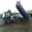

Epoch [1/60] Train Loss: 1.5516, Train Acc: 40.90% | Test Loss: 1.2551, Test Acc: 55.09% | LR: 0.000500
Epoch [2/60] Train Loss: 1.2334, Train Acc: 54.19% | Test Loss: 1.0034, Test Acc: 64.15% | LR: 0.000750
Epoch [3/60] Train Loss: 1.0861, Train Acc: 58.73% | Test Loss: 0.8592, Test Acc: 69.72% | LR: 0.001000
Epoch [4/60] Train Loss: 0.9727, Train Acc: 62.52% | Test Loss: 0.8038, Test Acc: 72.28% | LR: 0.001000
Epoch [5/60] Train Loss: 0.8437, Train Acc: 69.35% | Test Loss: 0.6805, Test Acc: 75.99% | LR: 0.000999
Epoch [6/60] Train Loss: 0.7976, Train Acc: 69.19% | Test Loss: 0.5891, Test Acc: 79.81% | LR: 0.000997
Epoch [7/60] Train Loss: 0.7230, Train Acc: 72.27% | Test Loss: 0.5801, Test Acc: 80.25% | LR: 0.000993
Epoch [8/60] Train Loss: 0.6796, Train Acc: 74.20% | Test Loss: 0.5221, Test Acc: 82.25% | LR: 0.000987
Epoch [9/60] Train Loss: 0.6856, Train Acc: 73.88% | Test Loss: 0.5055, Test Acc: 83.26% | LR: 0.000980
Epoch [10/60] Train Loss: 0.6672, Train Acc: 73.37% | Test Loss:

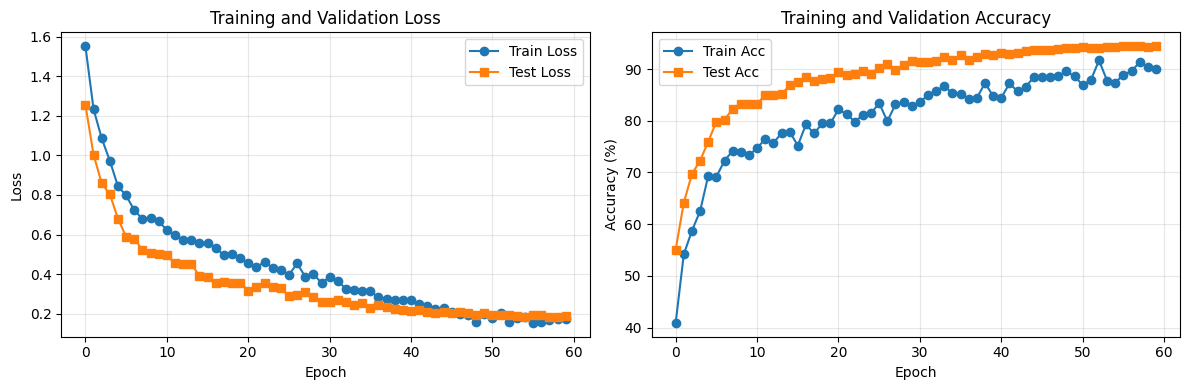

In [1]:
#The model is built based on the CIFAR-10 dataset. The model uses Resnet as the baseline model, adds SEblock, and uses basic data enhancement and mixup enhancement.
#The training configuration uses the Adam optimizer + Warmup + Cosine learning rate scheduling training, and the loss is selected as cross entropy
#Author: Yifan zhu

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt
import math
import torchvision.transforms as T
from google.colab.patches import cv2_imshow # openCV colab version
import cv2

# download Keras CIFAR-10 dataset
from tensorflow import keras
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print('train shape:', x_train.shape)
print('test shape:', x_test.shape)
print('label:', y_train.shape)
print('dtype:', x_train.dtype)
print('max:', x_train.max(), 'min:', x_train.min())
print('mean:', x_train.mean(), 'std:', x_train.std())
print('median:', np.median(x_train))
cv2_imshow(x_train[2])

#data normalization
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std  = [0.2470, 0.2435, 0.2616]

train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=cifar10_mean, std=cifar10_std),
    T.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), inplace=True),
])

test_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=cifar10_mean, std=cifar10_std),
])

# Dataset：numpy data application transform ===
class NumpyCIFAR(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images  # uint8, (N,32,32,3)
        self.labels = labels.squeeze().astype(np.int64)  # (N,)
        self.transform = transform
    def __len__(self):
        return self.images.shape[0]
    def __getitem__(self, idx):
        img = self.images[idx]     # HWC, uint8
        lab = self.labels[idx]     # int64
        if self.transform is not None:
            img = self.transform(img)  # CxHxW, float
        return img, lab


train_dataset = NumpyCIFAR(x_train, y_train, transform=train_transform)
test_dataset  = NumpyCIFAR(x_test,  y_test,  transform=test_transform)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Batch the processed data
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Channel Attention
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

#Residual blocks with channel and spatial attention
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, drop_rate=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.se    = SEBlock(out_channels, 8)
        
        self.dropout = nn.Dropout2d(drop_rate) if drop_rate > 0 else nn.Identity()
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x); out = self.bn1(out); out = F.relu(out); out = self.dropout(out)
        out = self.conv2(out); out = self.bn2(out)
        out = self.se(out)
        out = out + identity
        out = F.relu(out)
        return out

# The initial convolution + 4 residual blocks of resnet are used, and after convolution, GAP is used to summarize and flatten enter FC.
class cnn_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 5, 1, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.res_block1 = ResBlock(32, 64,  drop_rate=0.10)
        self.res_block2 = ResBlock(64, 64,  drop_rate=0.10)
        
        self.res_block3 = ResBlock(64, 128, stride=2, drop_rate=0.15)
        self.res_block4 = ResBlock(128, 128, stride=1, drop_rate=0.15)
        
        self.res_block5 = ResBlock(128, 256, stride=2, drop_rate=0.15)
        self.res_block6 = ResBlock(256, 256, stride=1, drop_rate=0.15)
        self.res_block7 = ResBlock(256, 256, stride=1, drop_rate=0.15)
        self.res_block8 = ResBlock(256, 256, stride=1, drop_rate=0.15)
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x); x = self.bn1(x); x = F.relu(x)     
        x = self.res_block1(x)       
        x = self.res_block2(x)        
        x = self.res_block3(x)     
        x = self.res_block4(x)    
        x = self.res_block5(x)    
        x = self.res_block6(x)
        x = self.res_block7(x)
        x = self.res_block8(x)
        x = self.global_avg_pool(x)  
        x = x.flatten(1)             
        x = self.fc(x)
        return x

model = cnn_model().to(device)
#remove annotations to view the model architecture
#summary(model, (3, 32, 32))

# Data augmentation
use_mixup = True
mixup_alpha = 0.3 #Mixing intensity
p_mix = 0.2  #Mixup trigger probability

def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, 1.0, None
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, (y_a, y_b), lam, index

def mixup_loss(criterion, pred, targets, lam):
    y_a, y_b = targets
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

#Train and eval part
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 60
warmup_epochs = 4
min_lr = 1e-6
base_lr = 1e-3

#warmup and cosineLR implementation
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(warmup_epochs)
    progress = (epoch - warmup_epochs) / max(1, (epochs - warmup_epochs))
    return min_lr / base_lr + 0.5 * (1 - min_lr / base_lr) * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

train_losses, test_losses, train_accs, test_accs = [], [], [], []

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, total = 0.0, 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()

        if use_mixup and (np.random.rand() < p_mix):#p_mix determines whether to mixup
            X_in, (ya, yb), lam, idx = mixup_data(X, y, alpha=mixup_alpha)
            out = model(X_in)
            loss = mixup_loss(criterion, out, (ya, yb), lam)
            pred = out.argmax(1)
            train_correct += (pred == y).sum().item()
        else:
            out = model(X)
            loss = criterion(out, y)#forward
            pred = out.argmax(1)
            train_correct += (pred == y).sum().item()

        loss.backward()#backporgation
        optimizer.step()#update weights

        batch = X.size(0)
        total += batch
        train_loss += loss.item()

    # eval
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            test_loss += loss.item()
            pred = out.argmax(1)
            test_correct += (pred == y).sum().item()
            test_total += y.size(0)

    train_losses.append(train_loss / len(train_loader))
    test_losses.append(test_loss / len(test_loader))
    train_accs.append(100.0 * train_correct / total)
    test_accs.append(100.0 * test_correct / test_total)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.2f}% | "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accs[-1]:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

# Visualization loss and accurancy curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Acc', marker='o')
ax2.plot(test_accs, label='Test Acc', marker='s')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

#save model
torch.save(model.state_dict(), "cnn_cifar10.pth")
